# **Data Preparation**

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Load the dataset
raw_data = pd.read_csv('insurance.csv')
# Display the first few rows of the dataset
print(raw_data.head())


   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [17]:
# Data Manipulation
# Check for missing values
print(raw_data.isnull().sum())
# Remove duplicates
clean_data = raw_data.drop_duplicates()
# Summary statistics
print(raw_data.describe())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
               age          bmi     children       charges
count  1337.000000  1337.000000  1337.000000   1337.000000
mean     39.222139    30.663452     1.095737  13279.121487
std      14.044333     6.100468     1.205571  12110.359656
min      18.000000    15.960000     0.000000   1121.873900
25%      27.000000    26.290000     0.000000   4746.344000
50%      39.000000    30.400000     1.000000   9386.161300
75%      51.000000    34.700000     2.000000  16657.717450
max      64.000000    53.130000     5.000000  63770.428010


In [39]:
# Numerical vs Categorical Data
num_cols = raw_data.select_dtypes(include=['float64', 'int64']).columns
uniq_num_values = raw_data[num_cols].nunique()

cat_cols = raw_data.select_dtypes(include=['object']).columns
uniq_cat_values = raw_data[cat_cols].nunique()

print("Numerical Columns:")
for col in num_cols:
    print(f"{col}: {uniq_num_values[col]}")
print("-" * 30 )
print("Categorical Columns:")
for col in cat_cols:
    print(f"{col}: {uniq_cat_values[col]} unique values ({clean_data[col].unique()})")

Numerical Columns:
age: 47
bmi: 548
children: 6
charges: 1337
------------------------------
Categorical Columns:
sex: 2 unique values (['female' 'male'])
smoker: 2 unique values (['yes' 'no'])
region: 4 unique values (['southwest' 'southeast' 'northwest' 'northeast'])


## **Data Exploration**

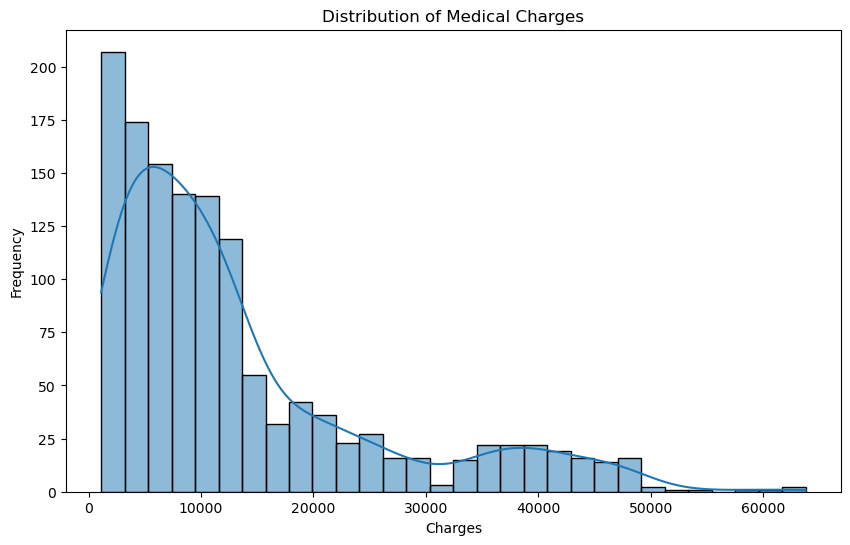

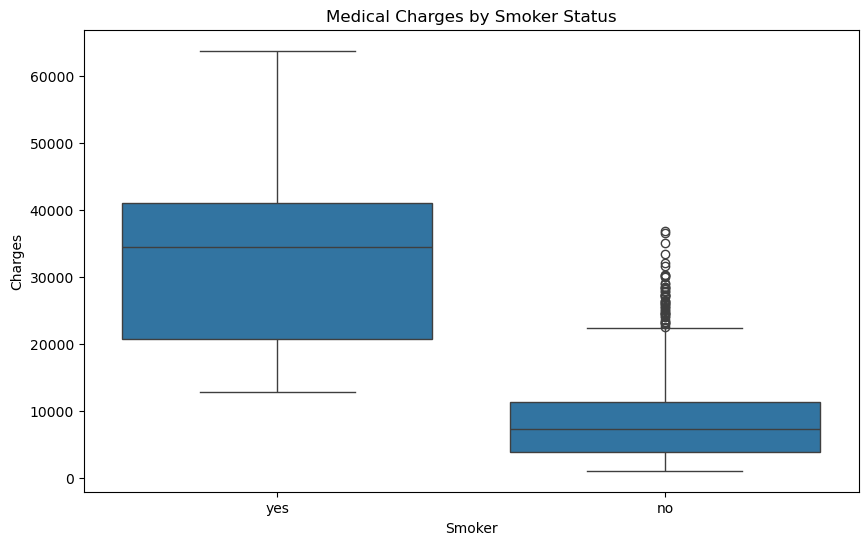

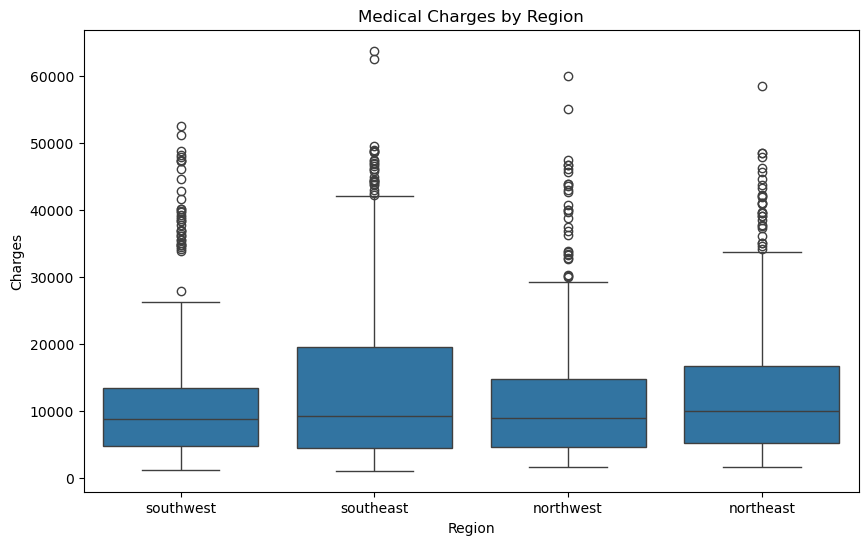

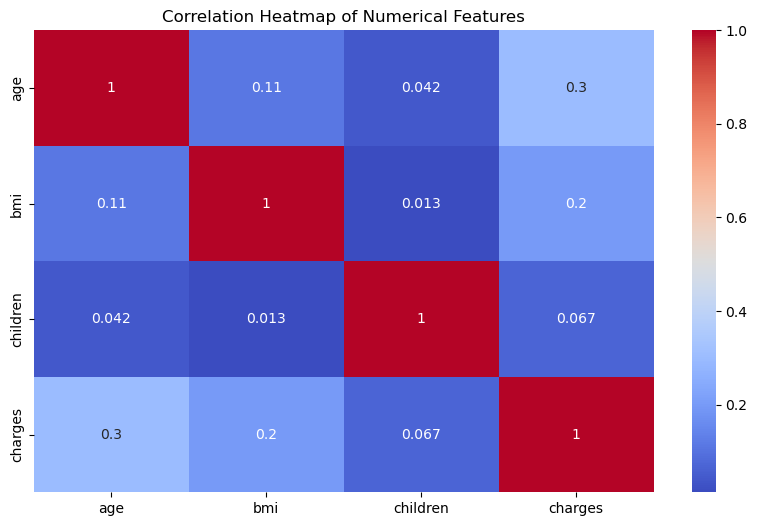

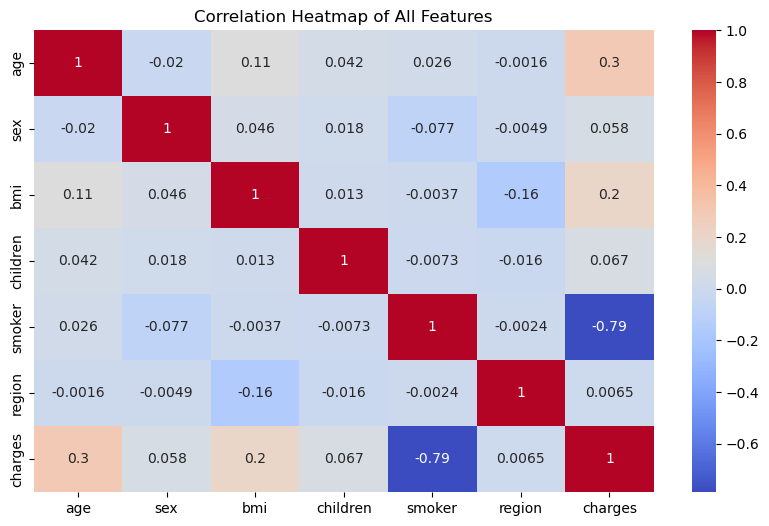

In [41]:
# Visualization
# Distribution of charges
plt.figure(figsize=(10, 6))
sns.histplot(clean_data['charges'], bins=30, kde=True)
plt.title('Distribution of Medical Charges')
plt.xlabel('Charges')
plt.ylabel('Frequency')
plt.show()

# Charges by smoker status
plt.figure(figsize=(10, 6))
sns.boxplot(x='smoker', y='charges', data=clean_data)
plt.title('Medical Charges by Smoker Status')
plt.xlabel('Smoker')
plt.ylabel('Charges')
plt.show()

# Charges by region
plt.figure(figsize=(10, 6))
sns.boxplot(x='region', y='charges', data=clean_data)
plt.title('Medical Charges by Region')
plt.xlabel('Region')
plt.ylabel('Charges')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 6))
sns.heatmap(clean_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Correlation between all features and charges
plt.figure(figsize=(10, 6))
# Create a copy with encoded categorical variables
encoded_data = clean_data.copy()
encoded_data['sex'] = pd.factorize(encoded_data['sex'])[0]
encoded_data['smoker'] = pd.factorize(encoded_data['smoker'])[0]
encoded_data['region'] = pd.factorize(encoded_data['region'])[0]
sns.heatmap(encoded_data.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of All Features')
plt.show()